In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

### W01A

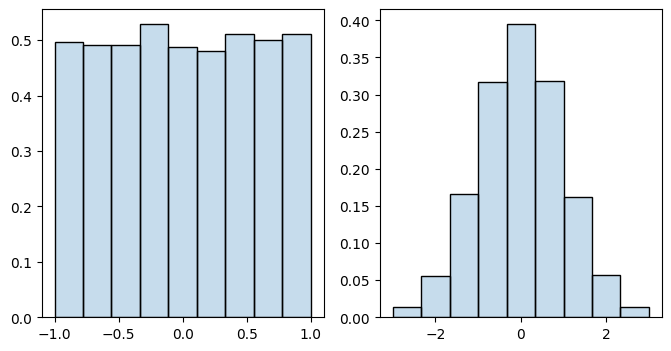

In [50]:
class Distribution():
    def __init__(self, xmin=0, xmax=1):
        self.xmin = xmin
        self.xmax = xmax
        self._set_xvals()

    def plot(self, ax):
        Nbins = 10
        xedges = np.linspace(self.xmin, self.xmax, Nbins)
        xcenters = (xedges[:-1] + xedges[1:]) / 2
        xwidth = xedges[1] - xedges[0]
        assert xwidth > 0
        bars, _ = np.histogram(self.xvals, xedges)
        P = bars / np.sum(bars) / xwidth
        ax.bar(xcenters, P, width=xwidth, facecolor='C0', alpha=0.25)
        ax.bar(xcenters, P, width=xwidth, facecolor='None', edgecolor='k')

class Uniform(Distribution):
    def _set_xvals(self):
        self.xvals = np.random.rand(10000) * (self.xmax-self.xmin) + self.xmin

class Normal(Distribution):
    def _set_xvals(self):
        self.xvals = np.random.randn(10000)

fig, axes = plt.subplots(1,2, figsize=(8,4))

uniform = Uniform(-1, 1)
normal = Normal(-3, 3)

for object, ax in zip((uniform, normal), axes):
    object.plot(ax)

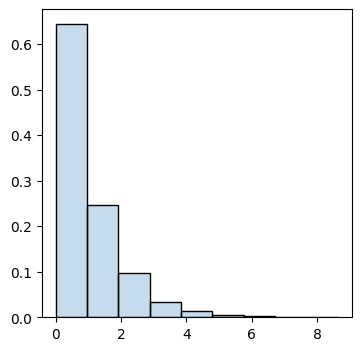

In [ ]:
class ExponentialDecay(Distribution):
    def __init__(self):
        self._get_uvals()
        self._get_samples()

    def _get_uvals(self):
        self.uvals = np.random.rand(10000)

    def _get_samples(self):
        # the cdf is the integral of e^(-x) from 0 to x  -->  F(x) = 1-e(-x)
        # the inverse is then -ln(1-x)
        self.xvals = [-np.log(1-x) for x in self.uvals]
        self.xmin = min(self.xvals)
        self.xmax = max(self.xvals)


exponential = ExponentialDecay()

fig, axes = plt.subplots(1,1,figsize=(4,4))
exponential.plot(axes)
    


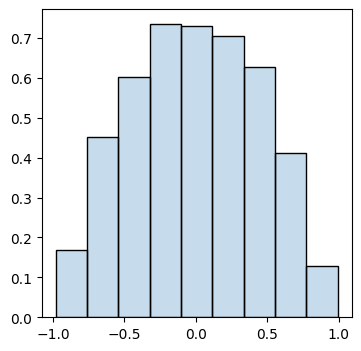

In [46]:
class ParabolicDensity(Distribution):
    def __init__(self):
        self._get_samples()

    def p(self, x):
        return 3/4 * (1-x**2)

    def _get_samples(self):
        self.xvals = []
        Nsamples = 10000
        Y = np.random.rand(Nsamples) * 3/4
        X = np.random.rand(Nsamples)*2 - 1    # -1 <= x <= 1
        # for i in range(Nsamples):
        #     y = 3/4 * U[i]
        #     x = X[i]
        #     if y < self.p(x):
        #         self.xvals.append((x,y))
        # return self.xvals
        accepted = Y < self.p(X)
        self.xvals = X[accepted]   #using masks
        self.xmin = min(self.xvals)
        self.xmax = max(self.xvals)
        return self.xvals

parabolic = ParabolicDensity()

fig, axes = plt.subplots(1,1,figsize=(4,4))

parabolic.plot(axes)
    

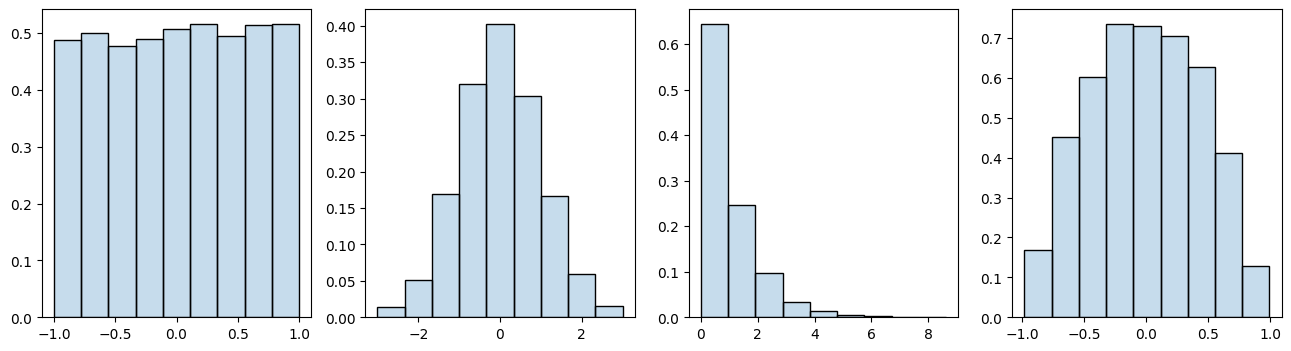

In [47]:
distributions = [uniform, normal, exponential, parabolic]
N = len(distributions)
fig , axes = plt.subplots (1, N, figsize = (4*N, 4))
for distribution, ax in zip(distributions, axes):
    distribution.plot(ax)